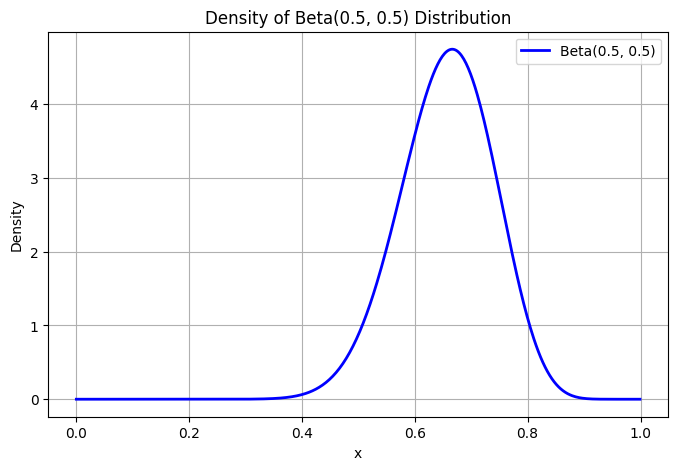

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define a grid avoiding the endpoints to prevent divergence issues
epsilon = 0.001
x = np.linspace(epsilon, 1 - epsilon, 500)

# Parameters: a = 0.5, b = 0.5
n = 30
k = 20
a = k+1
b = n - k +1
y = beta.pdf(x, a, b)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', lw=2, label='Beta(0.5, 0.5)')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density of Beta(0.5, 0.5) Distribution')
plt.legend()
plt.grid(True)
plt.show()


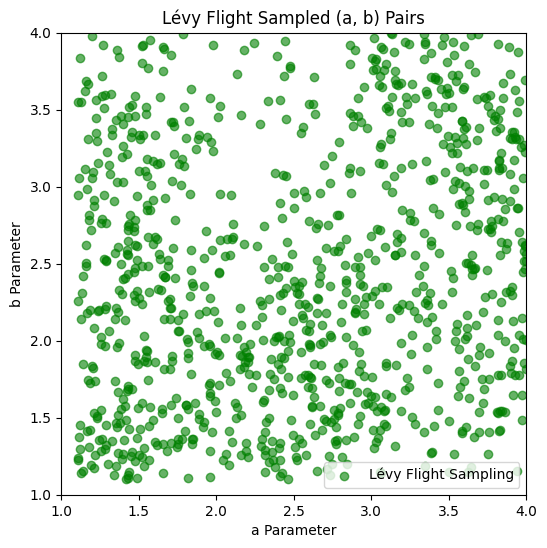

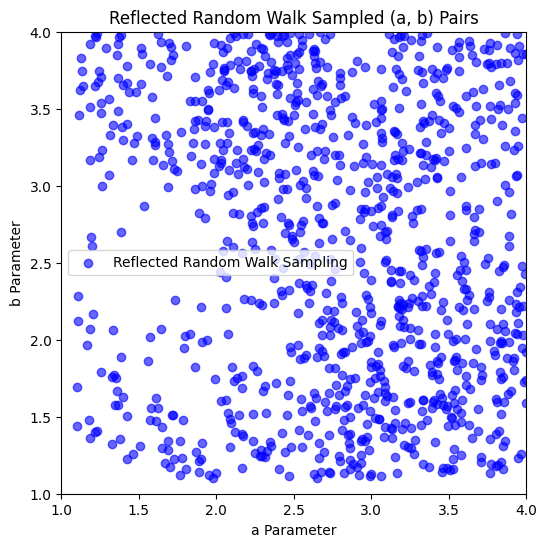

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_1samp

def reflect(value, lower, upper):
    """Reflects a value within the given bounds [lower, upper]."""
    range_size = upper - lower
    while value < lower or value > upper:
        if value < lower:
            value = lower + (lower - value)  # Reflect off the lower bound
        elif value > upper:
            value = upper - (value - upper)  # Reflect off the upper bound
    return value

def sample_random_walk_beta_params(K, min_ab=0.7, max_ab=10.0, step_size=0.1):
    """
    Generates K (a, b) pairs for Beta distributions using a random walk 
    with reflection to stay within bounds.

    Parameters:
        K : int
            Number of Beta distributions to sample.
        min_ab : float
            Minimum value for Beta parameters.
        max_ab : float
            Maximum value for Beta parameters.
        step_size : float
            Standard deviation of the random walk step (controls similarity).

    Returns:
        a_params, b_params : np.ndarray, np.ndarray
            Arrays of shape (K,) containing sampled Beta parameters.
    """
    a_params = np.zeros(K)
    b_params = np.zeros(K)

    # Initialize the first (a, b) pair randomly in the allowed range
    a_params[0] = np.random.uniform(min_ab, max_ab)
    b_params[0] = np.random.uniform(min_ab, max_ab)

    for i in range(1, K):
        # Propose new (a, b) using a small-step random walk
        a_new = a_params[i-1] + np.random.normal(scale=step_size)
        b_new = b_params[i-1] + np.random.normal(scale=step_size)

        # Reflect to stay within bounds
        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params

def sample_levy_flight_random_walk(K, min_ab=1.1, max_ab=4.0, step_size=0.1, exponent=3):
    """
    Generates K (a, b) parameters using a modified random walk with Lévy flight jumps.
    Instead of fully resetting uniformly, the jump is drawn from a heavy-tailed distribution
    (here, standard Cauchy) scaled to achieve the desired sup-norm error scaling of O(K^{-1/exponent}).

    Parameters:
      K         : int
                  Number of samples.
      min_ab    : float
                  Lower bound for the parameters.
      max_ab    : float
                  Upper bound for the parameters.
      step_size : float
                  Standard deviation for small local steps.
      exponent  : float
                  Target error scaling exponent; e.g. exponent=3 yields error ~ O(K^{-1/3}).

    Returns:
      a_params, b_params : np.ndarray
                           Arrays of sampled parameters.
    """
    a_params = np.zeros(K)
    b_params = np.zeros(K)
    
    # Initialize first values uniformly
    a_params[0] = np.random.uniform(min_ab, max_ab)
    b_params[0] = np.random.uniform(min_ab, max_ab)
    
    for i in range(1, K):
        # Take a small step (local correlation)
        a_new = a_params[i-1] + np.random.normal(scale=step_size)
        b_new = b_params[i-1] + np.random.normal(scale=step_size)
        
        # Occasionally take a Lévy flight jump
        if np.random.rand() < K**(-1/exponent):
            jump_scale = K**(-(1/2 - 1/exponent))  # Compute jump scale
            a_new += np.random.standard_cauchy() * jump_scale
            b_new += np.random.standard_cauchy() * jump_scale
        
        # Reflect to stay within bounds
        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params

# Example usage
K = 1000
a_levy, b_levy = sample_levy_flight_random_walk(K, min_ab=1.1, max_ab=4.0, step_size=0.2, exponent=3)

# Plot Lévy-flight-distributed samples
plt.figure(figsize=(6, 6))
plt.scatter(a_levy, b_levy, alpha=0.6, color='green', label="Lévy Flight Sampling")
plt.xlabel("a Parameter")
plt.ylabel("b Parameter")
plt.xlim(1, 4)  # Adjust x-axis based on data range
plt.ylim(1, 4)
plt.title("Lévy Flight Sampled (a, b) Pairs")
plt.legend()
plt.show()

a_rw, b_rw = sample_random_walk_beta_params(K, min_ab=1.1, max_ab=4.0, step_size=0.2)

# Plot reflected random walk samples
plt.figure(figsize=(6, 6))
plt.scatter(a_rw, b_rw, alpha=0.6, color='blue', label="Reflected Random Walk Sampling")
plt.xlabel("a Parameter")
plt.ylabel("b Parameter")
plt.xlim(1, 4)  # Adjust x-axis based on data range
plt.ylim(1, 4)
plt.title("Reflected Random Walk Sampled (a, b) Pairs")
plt.legend()
plt.show()


In [280]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet

def solve_optimal_weights(P, p_star):
    """
    Solve for weights q (of length K) that minimize ||Pq - p_star||^2,
    subject to q >= 0 and sum(q) == 1.
    """
    K = P.shape[1]
    q0 = np.ones(K) / K  # initial guess

    def objective(q):
        return np.sum((P @ q - p_star)**2)
    
    constraints = [{'type': 'eq', 'fun': lambda q: np.sum(q) - 1}]
    bounds = [(0, 1)] * K
    
    res = minimize(objective, q0, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x



def sample_uniform_beta_params(K, min_ab=0.7, max_ab=10.0):
    cat_probs = [0.25, 0.25, 0.25, 0.25]
    # Assign each of the K draws to one of the four categories
    cats = np.random.choice([0, 1, 2, 3], size=K, p=cat_probs)
    
    a_params = np.zeros(K)
    b_params = np.zeros(K)
    
    for i in range(K):
        cat = cats[i]
        if cat == 0:
            # Unimodal: a>1, b>1
            a_low, a_high = 1.0, max_ab
            b_low, b_high = 1.0, max_ab
        elif cat == 1:
            # Left skew: a<1, b>1
            a_low, a_high = min_ab, 1.0
            b_low, b_high = 1.0, max_ab
        elif cat == 2:
            # Right skew: a>1, b<1
            a_low, a_high = 1.0, max_ab
            b_low, b_high = min_ab, 1.0
        else:
            # U-shaped: a<1, b<1
            a_low, a_high = 1.0 - min_ab, 1.0
            b_low, b_high = 1.0 - min_ab, 1.0

        a_draw = np.random.uniform(min_ab, max_ab)
        b_draw = np.random.uniform(min_ab, max_ab)
        
        a_params[i] = a_draw
        b_params[i] = b_draw
    
    return a_params, b_params


def reflect(value, lower, upper):
    """Reflects a value within the given bounds [lower, upper]."""
    range_size = upper - lower
    while value < lower or value > upper:
        if value < lower:
            value = lower + (lower - value)  # Reflect off the lower bound
        elif value > upper:
            value = upper - (value - upper)  # Reflect off the upper bound
    return value

def sample_random_walk_beta_params(K, min_ab=0.7, max_ab=10.0, step_size=0.1):
    """
    Generates K (a, b) pairs for Beta distributions using a random walk 
    with reflection to stay within bounds.

    Parameters:
        K : int
            Number of Beta distributions to sample.
        min_ab : float
            Minimum value for Beta parameters.
        max_ab : float
            Maximum value for Beta parameters.
        step_size : float
            Standard deviation of the random walk step (controls similarity).

    Returns:
        a_params, b_params : np.ndarray, np.ndarray
            Arrays of shape (K,) containing sampled Beta parameters.
    """
    a_params = np.zeros(K)
    b_params = np.zeros(K)

    # Initialize the first (a, b) pair randomly in the allowed range
    a_params[0] = np.random.uniform(min_ab, max_ab)
    b_params[0] = np.random.uniform(min_ab, max_ab)

    for i in range(1, K):
        # Propose new (a, b) using a small-step random walk
        a_new = a_params[i-1] + np.random.normal(scale=step_size)
        b_new = b_params[i-1] + np.random.normal(scale=step_size)

        # Reflect to stay within bounds
        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params

def sample_levy_flight_random_walk(K, min_ab=1.1, max_ab=4.0, step_size=0.1, exponent=3):
    """
    Generates K (a, b) parameters using a modified random walk with Lévy flight jumps.
    Instead of fully resetting uniformly, the jump is drawn from a heavy-tailed distribution
    (here, standard Cauchy) scaled to achieve the desired sup-norm error scaling of O(K^{-1/exponent}).

    Parameters:
      K         : int
                  Number of samples.
      min_ab    : float
                  Lower bound for the parameters.
      max_ab    : float
                  Upper bound for the parameters.
      step_size : float
                  Standard deviation for small local steps.
      exponent  : float
                  Target error scaling exponent; e.g. exponent=3 yields error ~ O(K^{-1/3}).

    Returns:
      a_params, b_params : np.ndarray
                           Arrays of sampled parameters.
    """
    a_params = np.zeros(K)
    b_params = np.zeros(K)
    
    # Initialize first values uniformlya
    a_params[0] = np.random.uniform(min_ab, max_ab)
    b_params[0] = np.random.uniform(min_ab, max_ab)
    
    for i in range(1, K):
        # Take a small step (local correlation)
        a_new = a_params[i-1] + np.random.normal(scale=step_size)
        b_new = b_params[i-1] + np.random.normal(scale=step_size)
        
        # Occasionally take a Lévy flight jump
        if np.random.rand() < K**(-1/exponent):
            jump_scale = K**(-(1/2 - 1/exponent))  # Compute jump scale
            a_new += np.random.standard_cauchy() * jump_scale
            b_new += np.random.standard_cauchy() * jump_scale
        
        # Reflect to stay within bounds
        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params



def sample_counterfactual_beta_mixture(n_mixture, min_ab=0.7, max_ab=10.0, alpha=0.2, uniform = True):
    """
    Samples a counterfactual density that is a mixture of n_mixture Beta densities.
    
    1. It first samples (a, b) parameters using sample_uniform_beta_params.
    2. Then, it draws mixing weights from a Dirichlet distribution with concentration parameters 'alpha'.
    3. It returns a callable function `mixture_density` that computes the density
       at any point x, as well as the parameters and weights used.
       
    Using an alpha < 1 produces sparse weight vectors, so that often only a few components receive high mass.
    """
    # Sample parameters for the mixture components.
    a_params, b_params = sample_uniform_beta_params(n_mixture, min_ab, max_ab)
    
    # Sample mixing weights from a Dirichlet distribution with concentration parameter alpha
    weights = dirichlet.rvs(np.full(n_mixture, alpha))[0]
    if uniform:
        weights = np.ones_like(weights) / len(weights)
    
    # Define the mixture density function.
    def mixture_density(x):
        x = np.asarray(x)
        density = np.zeros_like(x, dtype=float)
        for i in range(n_mixture):
            density += weights[i] * beta.pdf(x, a_params[i], b_params[i])
        return density
    
    return mixture_density, a_params, b_params, weights


import numpy as np
from scipy.special import gamma

def beta_pdf(x, a, b):
    """
    Compute the Beta density at x given parameters a and b.
    
    Parameters:
        x : float or np.ndarray
            The point(s) at which to evaluate the density (should lie in [0,1]).
        a : float
            The first shape parameter.
        b : float
            The second shape parameter.
    
    Returns:
        float or np.ndarray: The beta density evaluated at x.
    """
    return (gamma(a + b) / (gamma(a) * gamma(b))) * (np.power(x, a - 1)) * (np.power(1 - x, b - 1))

def get_densities(a_params, b_params):
    """
    Returns two functions:
    
      - p_marginal(x): computes the marginal (mixture) density at x as the uniform average 
        of beta densities with parameters given by a_params and b_params.
        
      - p_conditional(x): given x, returns an (n x K) matrix where each column corresponds to 
        the conditional density of x for a given (a_k, b_k), i.e.,
            p_conditional_k(x) = Beta(x; a_k, b_k) / sum_{j=1}^K Beta(x; a_j, b_j)
    
    Parameters:
        a_params : list or np.ndarray
            List or array of 'a' parameters (shape parameters) for the beta densities.
        b_params : list or np.ndarray
            List or array of 'b' parameters for the beta densities.
    
    Returns:
        tuple: (p_marginal, p_conditional)
            - p_marginal: function that computes the marginal density at x.
            - p_conditional: function that computes a matrix of conditional densities at x.
    """
    # Ensure the parameters are numpy arrays.
    a_params = np.asarray(a_params)
    b_params = np.asarray(b_params)
    K = len(a_params)
    
    def p_marginal(x):
        """
        Compute the marginal density at x as a uniform mixture of the beta densities.
        
        Parameters:
            x : float or np.ndarray
                Evaluation point(s) in [0,1].
        
        Returns:
            np.ndarray: Marginal density evaluated at x.
        """
        x = np.atleast_1d(x)
        mixture = np.zeros_like(x, dtype=float)
        for a, b in zip(a_params, b_params):
            mixture += beta_pdf(x, a, b)
        return mixture / K  # uniform mixture over the K components
    
    def p_conditional(x):
        """
        For each evaluation point in x, compute the vector of conditional densities,
        i.e., the probability of being from each beta component given x.
        
        Parameters:
            x : float or np.ndarray
                Evaluation point(s) in [0,1].
        
        Returns:
            np.ndarray: An (n x K) matrix where n = len(x) and each column k is
                        Beta(x; a_k, b_k) divided by the sum over all components.
        """
        x = np.atleast_1d(x)
        n = x.shape[0]
        cond_matrix = np.zeros((n, K), dtype=float)
        # Compute the density for each component.
        for i, (a, b) in enumerate(zip(a_params, b_params)):
            cond_matrix[:, i] = beta_pdf(x, a, b)
        # Normalize each row so that the entries sum to 1.
        row_sums = np.sum(cond_matrix, axis=1)
        cond_matrix = cond_matrix / row_sums[:, None]
        return cond_matrix

    return p_marginal, p_conditional


# Approximation of structural parameter by mixture of beta densities

In [309]:
 a_params

array([2.6435672 , 2.65729123, 2.66852773, 2.67130293, 2.67496642,
       2.65522605, 2.66239727, 2.66664963, 2.6480663 , 2.65109323,
       2.65092994, 2.65710763, 2.63619633, 2.63705503, 2.63403399,
       2.65596635, 2.65824851, 2.65717936, 2.65455878, 2.65703175,
       2.64147958, 2.65393678, 2.65919927, 2.67024116, 2.67303715,
       2.6765171 , 2.678332  , 2.65866345, 2.66542558, 2.65802762,
       2.66129879, 2.66266801, 2.65262308, 2.65641967, 2.65003982,
       2.62896632, 2.61836887, 2.62013739, 2.61899187, 2.62896528,
       2.61368069, 2.6231593 , 2.61528455, 2.60867599, 2.62203945,
       2.61120336, 2.60349354, 2.60872392, 2.60576168, 2.60497877,
       2.61324412, 2.60329795, 2.6049441 , 2.61722288, 2.61758816,
       2.62211311, 2.6126957 , 2.60614651, 2.60066112, 2.59759278,
       2.60027732, 2.6007532 , 2.60589507, 2.60972687, 2.60876532,
       2.61431947, 2.61215121, 2.61503012, 2.60771143, 2.60271718,
       2.60202878, 2.58411546, 2.5747472 , 2.5716404 , 2.57921

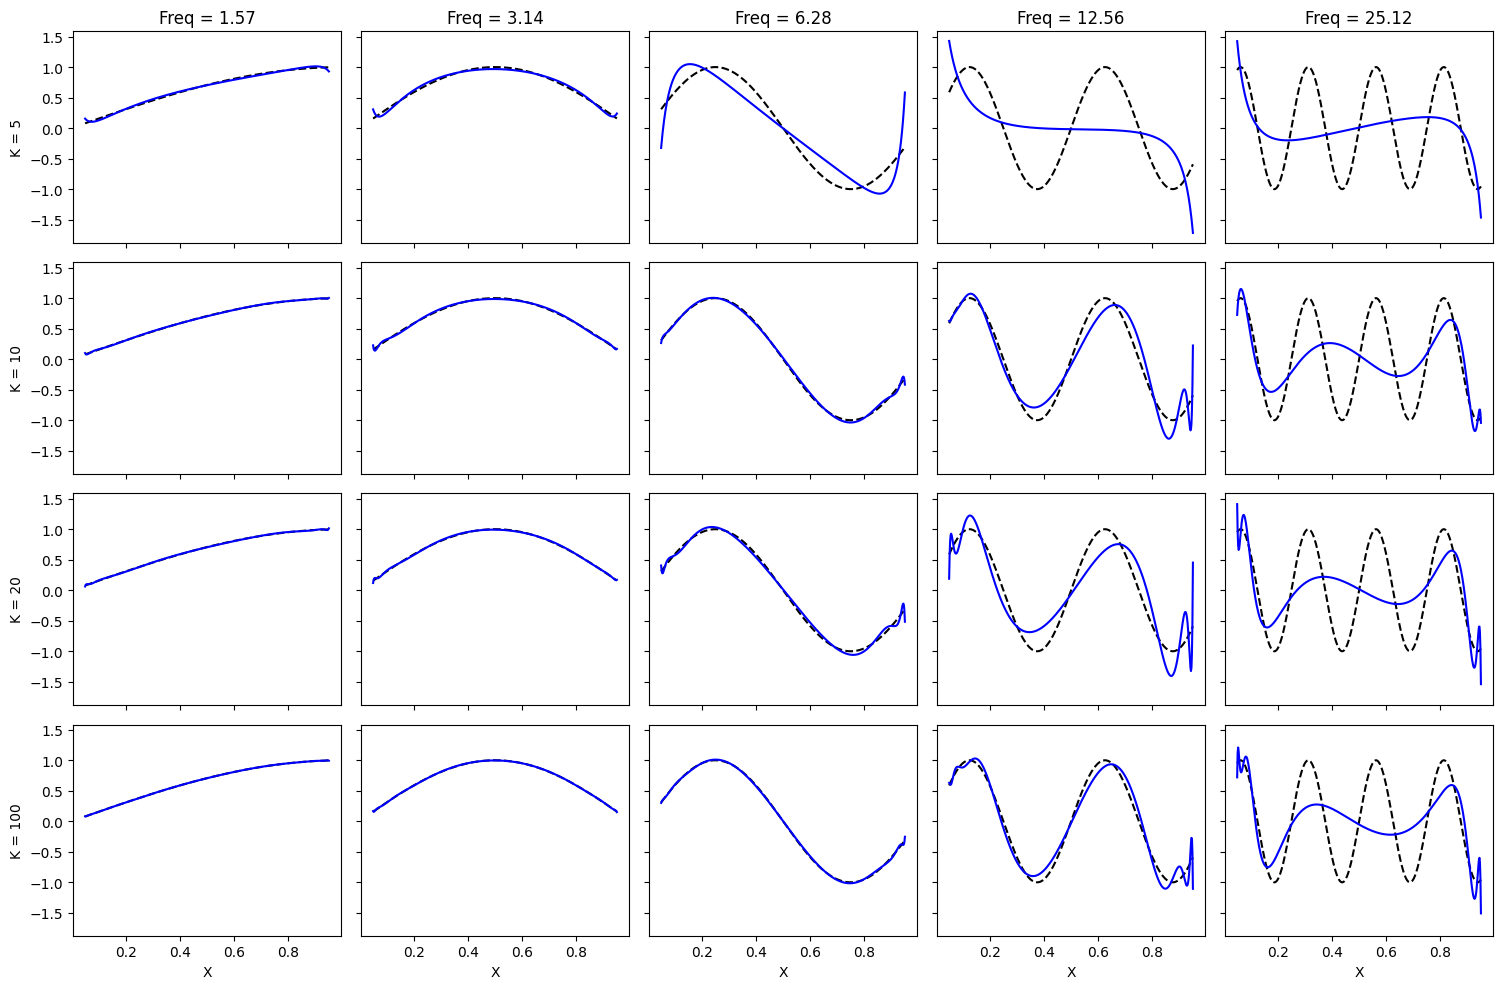

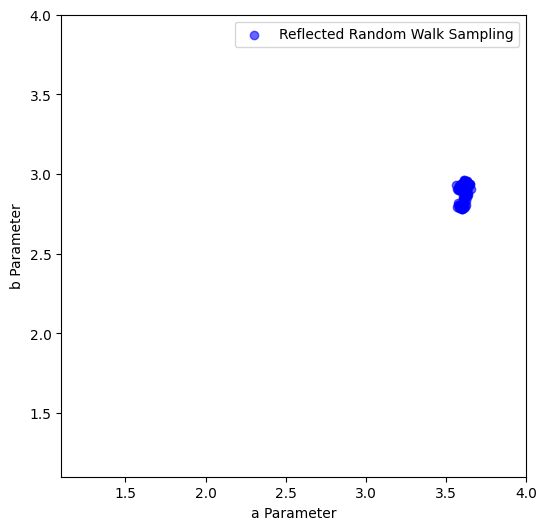

In [375]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid and parameters
n_grid = 500
epsilon = 0.05
x_grid = np.linspace(epsilon, 1 - epsilon, n_grid)
x_grid_predict = np.linspace(epsilon, 1 - epsilon, n_grid)
x_grid_predict = x_grid
# Values of K (number of Beta components)
K_values = [5, 10, 20, 100]

# Frequencies to test
pi = 3.14
frequencies = [pi / 2 * k for k in [1, 2, 4, 8, 16]]

# Create subplots: Rows = different K, Columns = different frequencies
fig, axes = plt.subplots(nrows=len(K_values), ncols=len(frequencies), figsize=(15, 10), sharex=True, sharey=True)

for i, K in enumerate(K_values):
    # Sample Beta parameters for this K
    range_ab = [1.1,4]
    a_params, b_params = sample_random_walk_beta_params(K, min_ab=range_ab[0], max_ab=range_ab[1], step_size=0.01)

    # Get marginal and conditional densities
    p_marginal, p_conditional = get_densities(a_params, b_params)

    # Compute marginal and conditional densities
    p = p_marginal(x_grid)
    P = p_conditional(x_grid)
    
    # Normalize columns
    P_norm = P / p[:, None]
    
    # SVD decomposition
    U, S, Vt = np.linalg.svd(P_norm, full_matrices=False)
    #P_norm = U # Orthonormal basis

    # Compute marginal and conditional densities for predictions
    p_pred = p_marginal(x_grid_predict)
    P_pred = p_conditional(x_grid_predict)

    # Normalize columns for predicted values
    P_norm_pred = P_pred / p_pred[:, None]

    # Project P_norm_pred onto the basis (corrected)
    U, S, Vt = np.linalg.svd(P_norm_pred, full_matrices=False)
    #P_norm_pred = P_norm_pred @ Vt.T @ np.diag(1 / S) 

    for j, freq in enumerate(frequencies):
        # Define h_true for the given frequency
        h_true = np.sin(freq * x_grid)
        h_true_predict = np.sin(freq * x_grid_predict)

        # Solve least squares for q
        q, _, _, _ = np.linalg.lstsq(P_norm, h_true, rcond=None)  # Least squares solution

        # Compute approximation
        h_approx = P_norm_pred @ q  # Use projected basis for prediction

        # Plot in subplot
        ax = axes[i, j]
        ax.plot(x_grid_predict, h_true_predict, label="True", linestyle="dashed", color="black")
        ax.plot(x_grid_predict, h_approx, label="Approx", color="blue")

        # Titles and labels
        if i == 0:
            ax.set_title(f"Freq = {freq:.2f}")
        if j == 0:
            ax.set_ylabel(f"K = {K}")
        if i == len(K_values) - 1:
            ax.set_xlabel("X")

# Adjust layout
plt.tight_layout()
plt.show()

# Scatter plot of Beta parameters
plt.figure(figsize=(6, 6))
plt.scatter(a_params, b_params, alpha=0.6, color='blue', label="Reflected Random Walk Sampling")
plt.xlabel("a Parameter")
plt.ylabel("b Parameter")

# Adjust limits dynamically based on sampled values
plt.xlim(min(range_ab), max(range_ab))
plt.ylim(min(range_ab), max(range_ab))

plt.legend()
plt.show()


In [373]:
U

array([[-0.36414127, -0.12785555,  0.29314871, ..., -0.00234207,
        -0.00055041,  0.06173683],
       [-0.33320971, -0.10442693,  0.22794009, ...,  0.00582795,
        -0.00116688, -0.06660347],
       [-0.30584882, -0.08457002,  0.17337531, ...,  0.00269619,
         0.01274287, -0.25287474],
       ...,
       [-0.01611188,  0.23392058,  0.12746486, ..., -0.02462619,
        -0.03636681,  0.07596748],
       [-0.01689422,  0.24759451,  0.13820919, ..., -0.03351772,
         0.05868566,  0.1929347 ],
       [-0.01774662,  0.26258947,  0.1501292 , ...,  0.01580427,
        -0.02126573, -0.1130502 ]], shape=(500, 100))

1

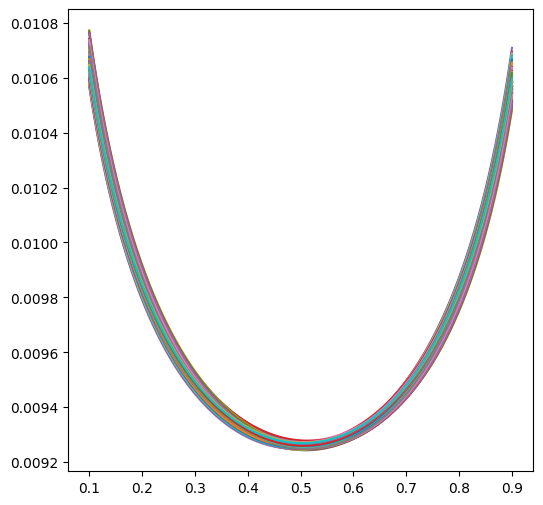

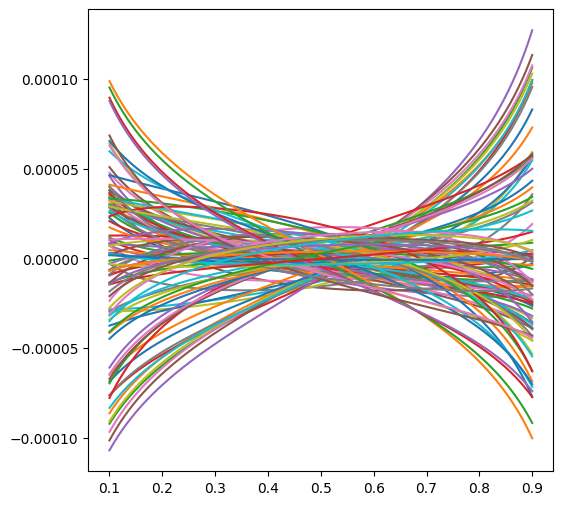

In [374]:
range_ab = [1.1, 1.2]
K = 100
epsilon = 0.1
x_grid = np.linspace(epsilon, 1 - epsilon, n_grid)
a_params, b_params = sample_random_walk_beta_params(K, min_ab=range_ab[0], max_ab=range_ab[1], step_size = 0.001)
p_marginal, p_conditional = get_densities(a_params, b_params)
p = p_marginal(x_grid)
P = p_conditional(x_grid)
P_norm = P / p[:, None]  # Normalize columns
plt.figure(figsize=(6, 6))
plt.plot(x_grid, P_norm)
plt.figure(figsize=(6, 6))
plt.plot(x_grid, P_norm - np.mean(P_norm, axis = 1)[:, None])
1

In [ ]:
# approximation of counterfactual density

In [340]:
q

array([-3.65059281e+09, -2.47576886e+10, -2.40572276e+10, -4.81526297e+09,
       -9.33836796e+09, -6.59073304e+09, -1.18524326e+10, -9.29590963e+09,
       -1.06472314e+10, -3.01800431e+09, -2.97589314e+09, -1.20191607e+10,
       -1.07171906e+10, -1.00584604e+10, -1.20196828e+10, -1.05214361e+10,
       -1.19213056e+10,  1.35127305e+09, -1.49532096e+09, -9.22675645e+09,
       -5.88357583e+09, -1.62201343e+10, -1.78125910e+10, -1.81732824e+10,
       -7.79491627e+09,  2.40058583e+10,  2.36109054e+10,  6.44627652e+10,
        7.31659314e+10,  1.77013610e+10, -1.74745352e+10, -2.67604072e+10,
       -2.28852861e+10, -5.10115068e+09, -8.48842797e+09, -1.44003308e+10,
       -1.19208487e+10, -1.03288917e+10, -3.39573746e+09, -1.16935532e+10,
       -1.40048921e+10, -6.90609892e+09,  1.19086795e+10,  1.27100603e+10,
       -5.48232875e+08, -4.37604179e+09, -5.23285720e+09, -3.91939822e+10,
       -3.72209924e+10, -1.35928022e+10, -9.32589301e+09,  1.18848023e+10,
        1.76822391e+10,  

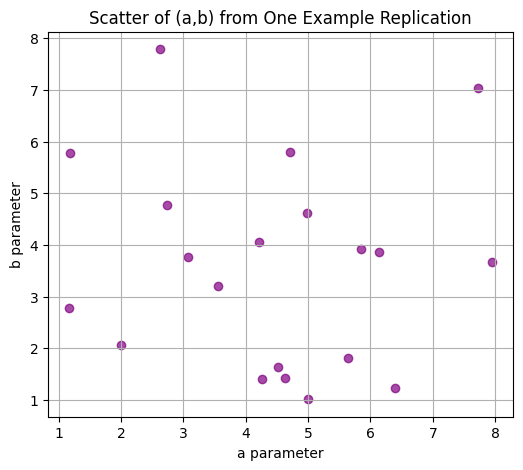

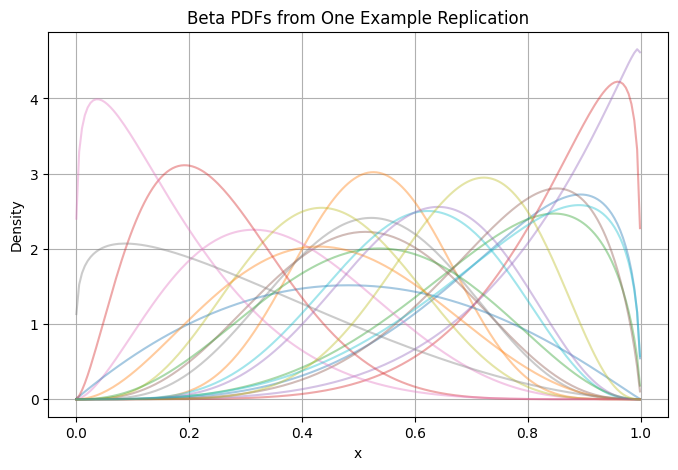

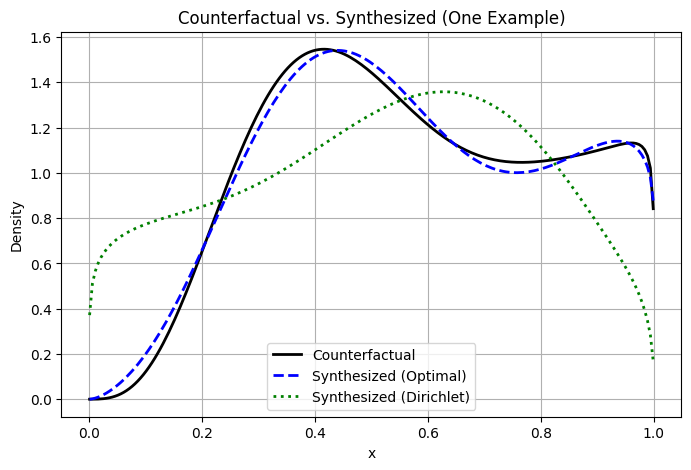

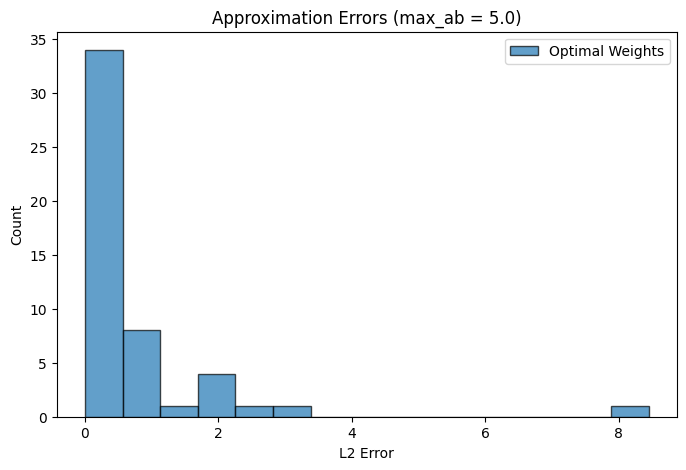

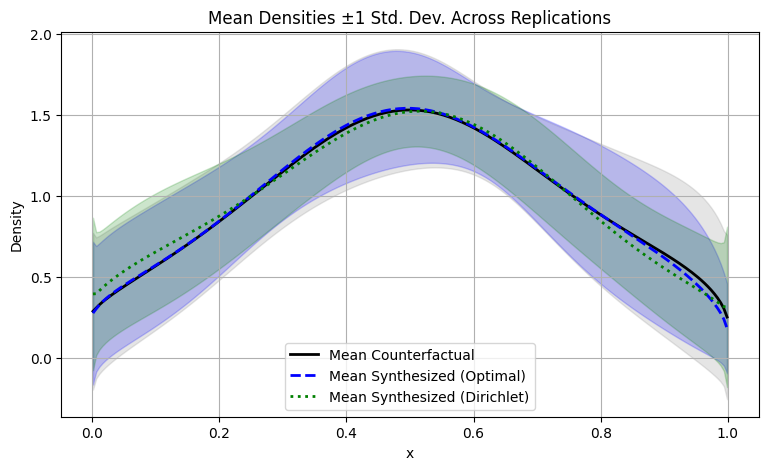

/var/folders/g5/l86dg6mx3ys0dyrlqq4pm1bh0000gn/T/ipykernel_32881/2340477983.py:239: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([errors_optimal, errors_dirichlet], labels=["Optimal", "Dirichlet"])


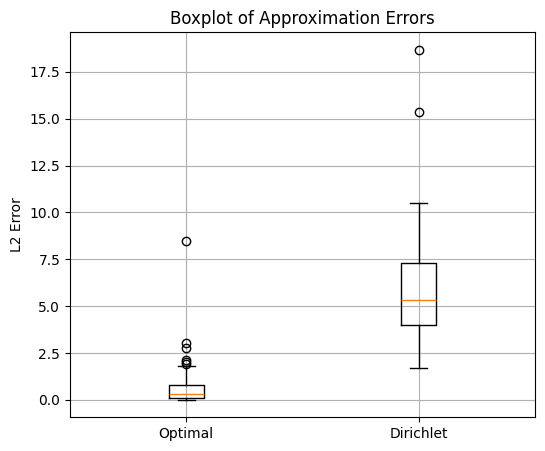

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet
 
 


# -------------------------------
# Main simulation code

K = 20               # Number of experiments (historical studies)
n_grid = 200          # Number of grid points on [0,1]
n_replications = 50   # Number of simulation replications
epsilon = 0.001
x_grid = np.linspace(epsilon, 1 - epsilon, n_grid)
range_ab = [0.75, 8.0]
range_ab_new = [0.75, 8]
n_mixture = 5        # Number of mixture components for the counterfactual
alpha = 1

errors_optimal = []
errors_dirichlet = []

# We'll store densities for all replications so we can compute mean ± std
all_p_star = []
all_p_synth_opt = []
all_p_synth_dir = []

# We'll also store one "example" replication for plotting the underlying Beta PDFs
example_a_params = None
example_b_params = None
example_P = None
example_p_star = None
example_p_synth_opt = None
example_p_synth_dir = None

for rep in range(n_replications):
    # Sample Beta parameters for K experiments
    a_params, b_params = sample_uniform_beta_params(K, min_ab=range_ab[0], max_ab=range_ab[1])
    
    # Evaluate Beta densities on the grid
    P = np.column_stack([beta.pdf(x_grid, a_params[k], b_params[k]) for k in range(K)])
    
    # Sample a new "counterfactual" distribution as a beta mixture.
    mixture_density, a_star_arr, b_star_arr, weights = sample_counterfactual_beta_mixture(n_mixture, alpha = alpha, min_ab=range_ab_new[0], max_ab=range_ab_new[1])
    # Evaluate the counterfactual mixture density on the grid.
    p_star = mixture_density(x_grid)
    
    # Solve for optimal weights
    q_opt = solve_optimal_weights(P, p_star)
    p_synth_opt = P @ q_opt
    error_opt = np.linalg.norm(p_synth_opt - p_star)
    
    # Random Dirichlet weights
    q_dir = dirichlet.rvs(np.ones(K))[0]
    p_synth_dir = P @ q_dir
    error_dir = np.linalg.norm(p_synth_dir - p_star)
    
    # Store errors if valid
    if np.isfinite(error_opt) and np.isfinite(error_dir):
        errors_optimal.append(error_opt)
        errors_dirichlet.append(error_dir)
        all_p_star.append(p_star)
        all_p_synth_opt.append(p_synth_opt)
        all_p_synth_dir.append(p_synth_dir)
        
        # Store one example replication for plotting the actual Beta PDFs
        if example_a_params is None:
            example_a_params = a_params
            example_b_params = b_params
            example_P = P
            example_p_star = p_star
            example_p_synth_opt = p_synth_opt
            example_p_synth_dir = p_synth_dir

# Convert to numpy arrays
errors_optimal = np.array(errors_optimal)
errors_dirichlet = np.array(errors_dirichlet)
all_p_star = np.array(all_p_star)
all_p_synth_opt = np.array(all_p_synth_opt)
all_p_synth_dir = np.array(all_p_synth_dir)

# --- 1) Plot the (a,b) scatter and Beta PDFs from the example replication ---
if example_a_params is not None:
    # Scatter plot of (a,b)
    plt.figure(figsize=(6,5))
    plt.scatter(example_a_params, example_b_params, c='purple', alpha=0.7)
    plt.xlabel("a parameter")
    plt.ylabel("b parameter")
    plt.title("Scatter of (a,b) from One Example Replication")
    plt.grid(True)
    plt.show()
    
    # Plot the Beta PDFs from that replication
    plt.figure(figsize=(8,5))
    for k in range(K):
        plt.plot(x_grid, example_P[:, k], alpha=0.4)
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Beta PDFs from One Example Replication")
    plt.grid(True)
    plt.show()

    # Plot the counterfactual vs. synthesized densities for that example
    plt.figure(figsize=(8,5))
    plt.plot(x_grid, example_p_star, 'k-', lw=2, label="Counterfactual")
    plt.plot(x_grid, example_p_synth_opt, 'b--', lw=2, label="Synthesized (Optimal)")
    plt.plot(x_grid, example_p_synth_dir, 'g:', lw=2, label="Synthesized (Dirichlet)")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Counterfactual vs. Synthesized (One Example)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 2) Plot histograms of L2 errors ---
if errors_optimal.size > 0 and errors_dirichlet.size > 0:
    plt.figure(figsize=(8,5))
    plt.hist(errors_optimal, bins=15, alpha=0.7, label='Optimal Weights', edgecolor='black')
   # plt.hist(errors_dirichlet, bins=15, alpha=0.7, label='Dirichlet Weights', edgecolor='black')
    plt.xlabel("L2 Error")
    plt.ylabel("Count")
    plt.title("Approximation Errors (max_ab = {:.1f})".format(max_ab))
    plt.legend()
    plt.show()

# --- 3) Plot mean ± std of the densities across replications ---
if all_p_star.shape[0] > 0:
    mean_p_star = np.mean(all_p_star, axis=0)
    std_p_star = np.std(all_p_star, axis=0)
    mean_p_synth_opt = np.mean(all_p_synth_opt, axis=0)
    std_p_synth_opt = np.std(all_p_synth_opt, axis=0)
    mean_p_synth_dir = np.mean(all_p_synth_dir, axis=0)
    std_p_synth_dir = np.std(all_p_synth_dir, axis=0)

    plt.figure(figsize=(9,5))
    plt.plot(x_grid, mean_p_star, 'k-', label="Mean Counterfactual", lw=2)
    plt.fill_between(x_grid, mean_p_star - std_p_star, mean_p_star + std_p_star,
                     color="gray", alpha=0.2)
    
    plt.plot(x_grid, mean_p_synth_opt, 'b--', label="Mean Synthesized (Optimal)", lw=2)
    plt.fill_between(x_grid, mean_p_synth_opt - std_p_synth_opt,
                     mean_p_synth_opt + std_p_synth_opt, color="blue", alpha=0.2)
    
    plt.plot(x_grid, mean_p_synth_dir, 'g:', label="Mean Synthesized (Dirichlet)", lw=2)
    plt.fill_between(x_grid, mean_p_synth_dir - std_p_synth_dir,
                     mean_p_synth_dir + std_p_synth_dir, color="green", alpha=0.2)

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Mean Densities ±1 Std. Dev. Across Replications")
    plt.legend()
    plt.grid(True)
    plt.show()

 


In [ ]:
T_star <-

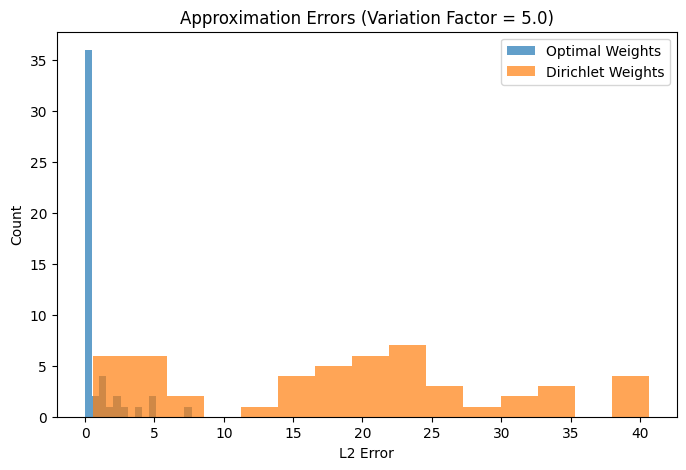

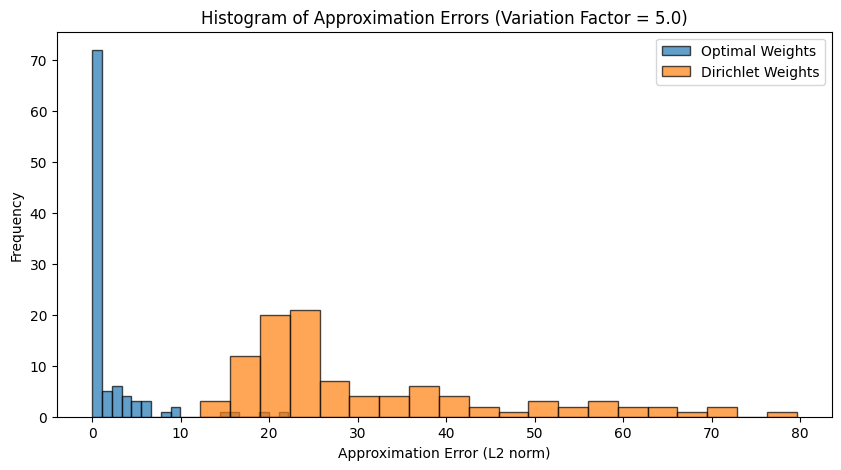

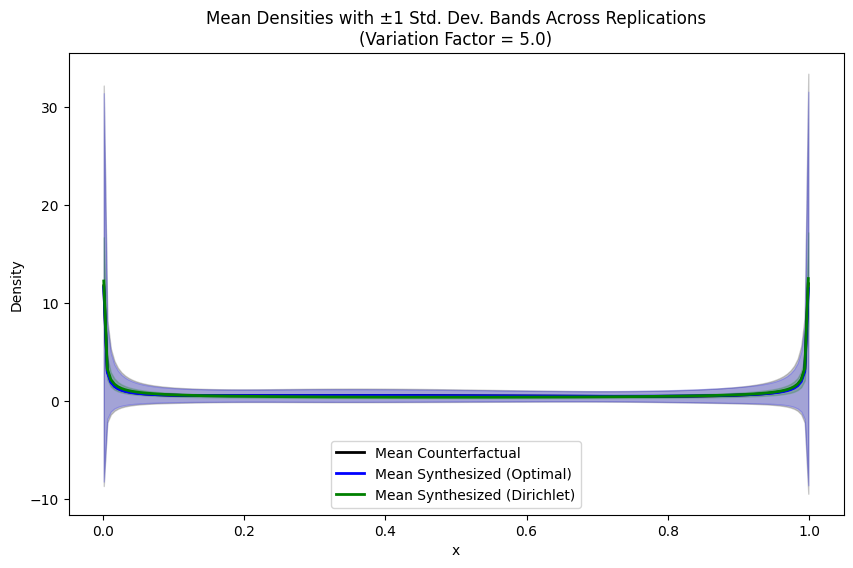

/var/folders/g5/l86dg6mx3ys0dyrlqq4pm1bh0000gn/T/ipykernel_32881/3323260005.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([errors_optimal, errors_dirichlet], labels=["Optimal", "Dirichlet"])


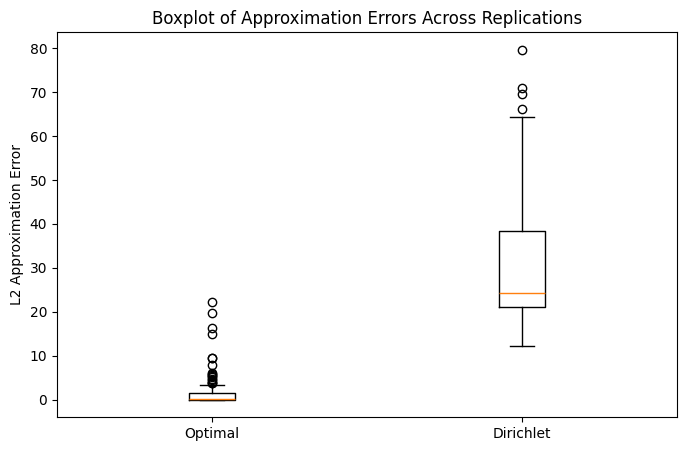

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet, gamma

def solve_optimal_weights(P, p_star):
    """
    Solve for weights q (of length K) that minimize ||Pq - p_star||^2,
    subject to q >= 0 and sum(q) == 1.
    """
    K = P.shape[1]
    q0 = np.ones(K) / K  # initial guess

    def objective(q):
        return np.sum((P @ q - p_star) ** 2)
    
    constraints = [{'type': 'eq', 'fun': lambda q: np.sum(q) - 1}]
    bounds = [(0, 1)] * K
    
    res = minimize(objective, q0, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x

# Simulation parameters
K = 50              # Number of experiments (historical studies)
n_grid = 200        # Number of grid points on [0,1]
n_replications = 100# Number of simulation replications

# Avoid endpoints to prevent infinite density values
epsilon = 0.001
x_grid = np.linspace(epsilon, 1 - epsilon, n_grid)

# -------------------------------
# Variation parameter: controls how diverse the densities are.
# Lower variation: variation_factor = 1.0 (mu ~ Beta(2,2))
# Higher variation: variation_factor > 1 (e.g., 5.0 gives mu ~ Beta(0.4,0.4))
variation_factor = 5.0  # Try 1.0 for low variation; 5.0 (or higher) for high variation

mu_alpha = 2.0 / variation_factor
mu_beta = 2.0 / variation_factor
# We keep the phi prior fixed:
phi_shape, phi_scale = 2, 2  # phi ~ Gamma(2, 2), mean = 4

# Lists to store error metrics and densities across replications.
errors_optimal = []
errors_dirichlet = []
all_p_star = []         # Counterfactual densities
all_p_synth_opt = []    # Synthesized densities (optimal weights)
all_p_synth_dir = []    # Synthesized densities (Dirichlet weights)
example_results = None

for rep in range(n_replications):
    try:
        # Sample mu and phi for each experiment.
        mu_params = np.random.beta(mu_alpha, mu_beta, size=K)
        phi_params = np.random.gamma(shape=phi_shape, scale=phi_scale, size=K)
        a_params = mu_params * phi_params
        b_params = (1 - mu_params) * phi_params

        # Evaluate the Beta densities on the grid for each experiment.
        P = np.column_stack([beta.pdf(x_grid, a_params[k], b_params[k]) for k in range(K)])
        
        # Sample counterfactual parameters from the same priors.
        mu_star = np.random.beta(mu_alpha, mu_beta)
        phi_star = np.random.gamma(shape=phi_shape, scale=phi_scale)
        a_star = mu_star * phi_star
        b_star = (1 - mu_star) * phi_star
        p_star = beta.pdf(x_grid, a_star, b_star)
        
        # Compute the synthesized density using optimal weights.
        q_opt = solve_optimal_weights(P, p_star)
        p_synth_opt = P @ q_opt
        error_opt = np.linalg.norm(p_synth_opt - p_star)
        
        # Compute the synthesized density using Dirichlet weights.
        q_dir = dirichlet.rvs(np.ones(K))[0]
        p_synth_dir = P @ q_dir
        error_dir = np.linalg.norm(p_synth_dir - p_star)
        
        # Store errors and densities if valid.
        if np.isfinite(error_opt) and np.isfinite(error_dir):
            errors_optimal.append(error_opt)
            errors_dirichlet.append(error_dir)
            all_p_star.append(p_star)
            all_p_synth_opt.append(p_synth_opt)
            all_p_synth_dir.append(p_synth_dir)
            if example_results is None:
                example_results = {
                    'P': P,
                    'p_star': p_star,
                    'q_opt': q_opt,
                    'p_synth_opt': p_synth_opt,
                    'q_dir': q_dir,
                    'p_synth_dir': p_synth_dir,
                    'a_star': a_star,
                    'b_star': b_star
                }
    except Exception as e:
        print(f"Replication {rep} skipped due to error: {e}")

errors_optimal = np.array(errors_optimal)
errors_dirichlet = np.array(errors_dirichlet)
errors_optimal = errors_optimal[np.isfinite(errors_optimal)]
errors_dirichlet = errors_dirichlet[np.isfinite(errors_dirichlet)]

# Histogram of approximation errors.
if errors_optimal.size > 0 and errors_dirichlet.size > 0:
    plt.figure(figsize=(10, 5))
    plt.hist(errors_optimal, bins=20, alpha=0.7, label='Optimal Weights', edgecolor='black')
    plt.hist(errors_dirichlet, bins=20, alpha=0.7, label='Dirichlet Weights', edgecolor='black')
    plt.xlabel("Approximation Error (L2 norm)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Approximation Errors (Variation Factor = {:.1f})".format(variation_factor))
    plt.legend()
    plt.show()
else:
    print("No valid error values to plot.")

# Plot mean and standard deviation bands across replications.
if all_p_star:
    all_p_star = np.array(all_p_star)
    all_p_synth_opt = np.array(all_p_synth_opt)
    all_p_synth_dir = np.array(all_p_synth_dir)

    mean_p_star = np.mean(all_p_star, axis=0)
    std_p_star = np.std(all_p_star, axis=0)
    mean_p_synth_opt = np.mean(all_p_synth_opt, axis=0)
    std_p_synth_opt = np.std(all_p_synth_opt, axis=0)
    mean_p_synth_dir = np.mean(all_p_synth_dir, axis=0)
    std_p_synth_dir = np.std(all_p_synth_dir, axis=0)

    plt.figure(figsize=(10, 6))
    # Plot mean counterfactual density with error band.
    plt.plot(x_grid, mean_p_star, label="Mean Counterfactual", color="black", lw=2)
    plt.fill_between(x_grid, mean_p_star - std_p_star, mean_p_star + std_p_star,
                     color="black", alpha=0.2)
    # Plot mean synthesized density (optimal weights) with error band.
    plt.plot(x_grid, mean_p_synth_opt, label="Mean Synthesized (Optimal)", color="blue", lw=2)
    plt.fill_between(x_grid, mean_p_synth_opt - std_p_synth_opt, mean_p_synth_opt + std_p_synth_opt,
                     color="blue", alpha=0.2)
    # Plot mean synthesized density (Dirichlet weights) with error band.
    plt.plot(x_grid, mean_p_synth_dir, label="Mean Synthesized (Dirichlet)", color="green", lw=2)
    plt.fill_between(x_grid, mean_p_synth_dir - std_p_synth_dir, mean_p_synth_dir + std_p_synth_dir,
                     color="green", alpha=0.2)
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title("Mean Densities with ±1 Std. Dev. Bands Across Replications\n(Variation Factor = {:.1f})".format(variation_factor))
    plt.legend()
    plt.show()
else:
    print("No valid density data to plot.")

# (Optional) Also show a boxplot of L2 errors across replications.
if errors_optimal.size > 0 and errors_dirichlet.size > 0:
    plt.figure(figsize=(8,5))
    plt.boxplot([errors_optimal, errors_dirichlet], labels=["Optimal", "Dirichlet"])
    plt.ylabel("L2 Approximation Error")
    plt.title("Boxplot of Approximation Errors Across Replications")
    plt.show()


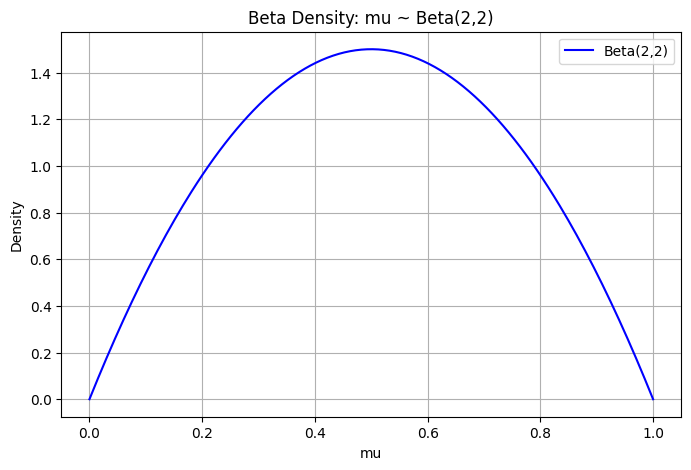

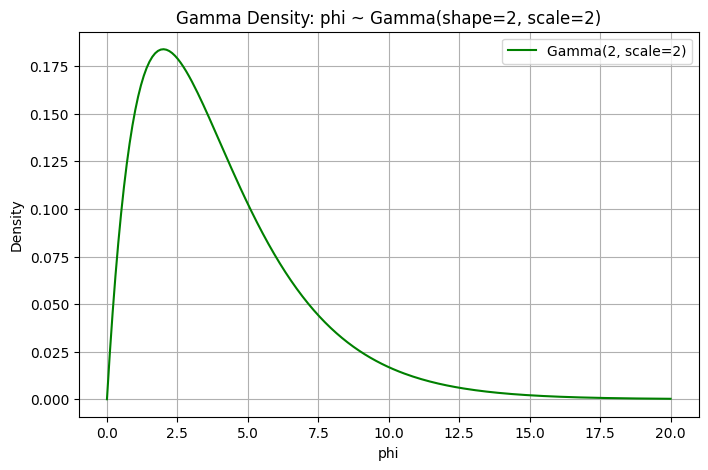

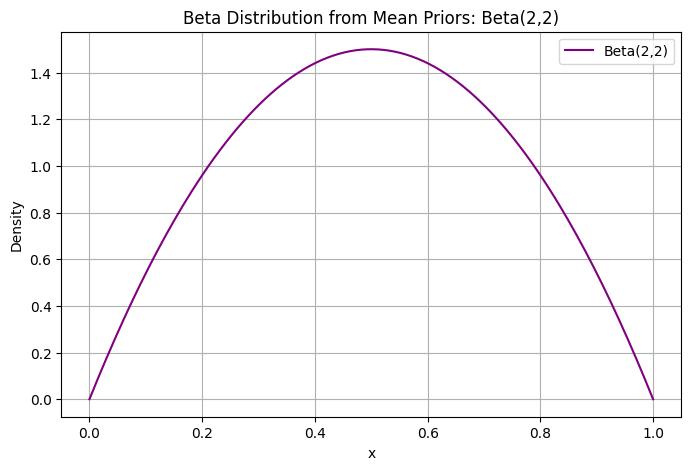

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, gamma

# Plot for the Beta prior on mu: mu ~ Beta(2,2)
x_beta = np.linspace(0, 1, 200)
y_beta = beta.pdf(x_beta, 2, 2)

plt.figure(figsize=(8, 5))
plt.plot(x_beta, y_beta, label='Beta(2,2)', color='blue')
plt.xlabel('mu')
plt.ylabel('Density')
plt.title('Beta Density: mu ~ Beta(2,2)')
plt.legend()
plt.grid(True)
plt.show()

# Plot for the Gamma prior on phi: phi ~ Gamma(shape=2, scale=2)
x_gamma = np.linspace(0, 20, 200)
y_gamma = gamma.pdf(x_gamma, a=2, scale=2)

plt.figure(figsize=(8, 5))
plt.plot(x_gamma, y_gamma, label='Gamma(2, scale=2)', color='green')
plt.xlabel('phi')
plt.ylabel('Density')
plt.title('Gamma Density: phi ~ Gamma(shape=2, scale=2)')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Mean values from the priors:
mu_mean = 0.5          # Mean of Beta(2,2) is 0.5
phi_mean = 4.0         # Mean of Gamma(2,2) is 4
a_mean = mu_mean * phi_mean  # 0.5 * 4 = 2
b_mean = (1 - mu_mean) * phi_mean  # 0.5 * 4 = 2

# Generate the Beta(2,2) density
x = np.linspace(0, 1, 200)
y = beta.pdf(x, a_mean, b_mean)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Beta(2,2)', color='purple')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Beta Distribution from Mean Priors: Beta(2,2)')
plt.legend()
plt.grid(True)
plt.show()

